# Bayesian Statistics
### Interactive Notebook for AI/ML Interview Preparation

Covers priors, posteriors, conjugate models, MAP vs MLE, MCMC, and Bayesian updating.

📺 **Video Lecture:** [https://youtu.be/YpckH7F5vj0](https://youtu.be/YpckH7F5vj0)

In [2]:
# Prerequisites
# !pip install numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


---
## 1. Prior, Likelihood, and Posterior

**Bayes' Rule:** posterior ∝ likelihood × prior
$$P(\theta|D) = \frac{P(D|\theta) \cdot P(\theta)}{P(D)}$$

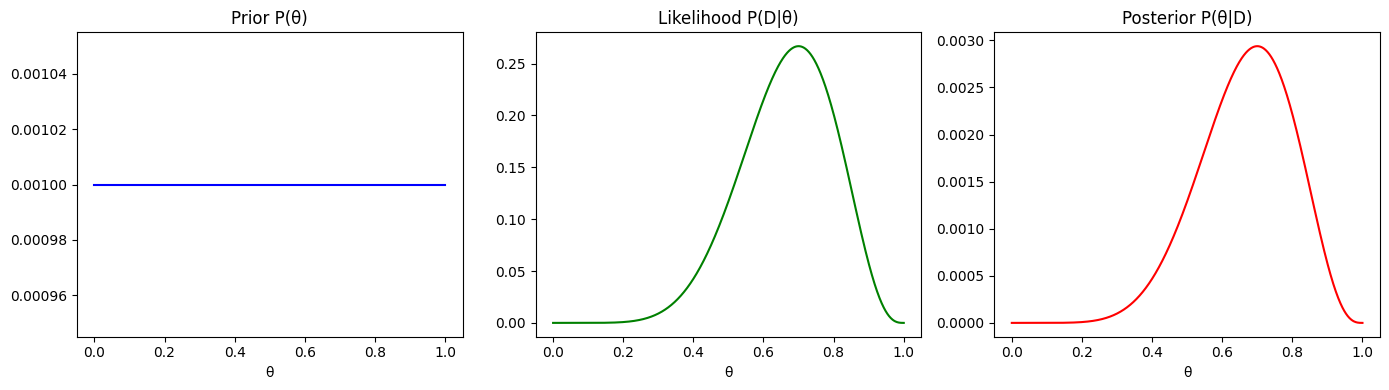

MAP estimate: 0.700 (mode of posterior)
MLE estimate: 0.700 (maximum of likelihood)


In [3]:
# Grid-based Bayesian inference for a coin's bias
# Prior: what we believe about theta (probability of heads) before data
theta = np.linspace(0, 1, 1000)

# Flat (uninformative) prior
prior = np.ones_like(theta)
prior /= prior.sum()

# Data: observe 7 heads in 10 flips
n_heads, n_flips = 7, 10
likelihood = stats.binom.pmf(n_heads, n_flips, theta)

# Posterior = likelihood * prior (unnormalized), then normalize
posterior = likelihood * prior
posterior /= posterior.sum()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(theta, prior, 'b-'); axes[0].set_title('Prior P(θ)'); axes[0].set_xlabel('θ')
axes[1].plot(theta, likelihood, 'g-'); axes[1].set_title('Likelihood P(D|θ)'); axes[1].set_xlabel('θ')
axes[2].plot(theta, posterior, 'r-'); axes[2].set_title('Posterior P(θ|D)'); axes[2].set_xlabel('θ')
plt.tight_layout()
plt.show()
print(f'MAP estimate: {theta[np.argmax(posterior)]:.3f} (mode of posterior)')
print(f'MLE estimate: {n_heads/n_flips:.3f} (maximum of likelihood)')

---
## 2. Beta-Binomial Conjugate Model

The Beta distribution is the conjugate prior for the Binomial likelihood.  
If prior is Beta(α, β), after observing h heads in n flips, posterior is Beta(α+h, β+n-h).

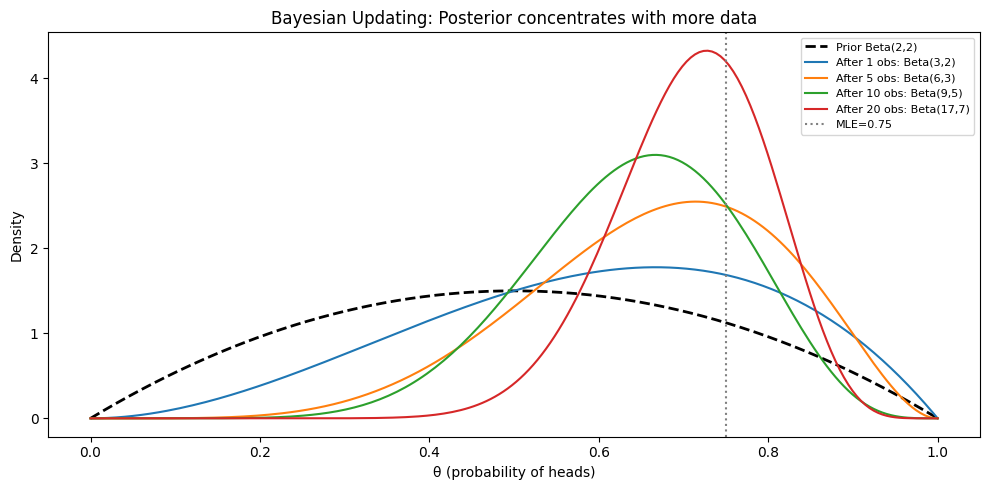

In [4]:
# Sequential Bayesian updating with Beta-Binomial
alpha_prior, beta_prior = 2, 2  # Slightly informative prior
observations = [1,1,0,1,1,1,0,1,0,1,1,1,0,1,1,1,1,0,1,1]  # 1=heads

fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 1, 200)

# Plot prior
ax.plot(x, stats.beta.pdf(x, alpha_prior, beta_prior), 'k--', label='Prior Beta(2,2)', linewidth=2)

# Update sequentially
a, b = alpha_prior, beta_prior
for i, obs in enumerate(observations):
    a += obs
    b += (1 - obs)
    if i+1 in [1, 5, 10, 20]:
        ax.plot(x, stats.beta.pdf(x, a, b), label=f'After {i+1} obs: Beta({a},{b})')

ax.axvline(x=sum(observations)/len(observations), color='gray', linestyle=':', label=f'MLE={sum(observations)/len(observations):.2f}')
ax.set_xlabel('θ (probability of heads)')
ax.set_ylabel('Density')
ax.set_title('Bayesian Updating: Posterior concentrates with more data')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. MAP vs MLE

- **MLE** maximizes P(D|θ) — ignores prior
- **MAP** maximizes P(θ|D) ∝ P(D|θ)·P(θ) — includes prior
- With flat prior, MAP = MLE

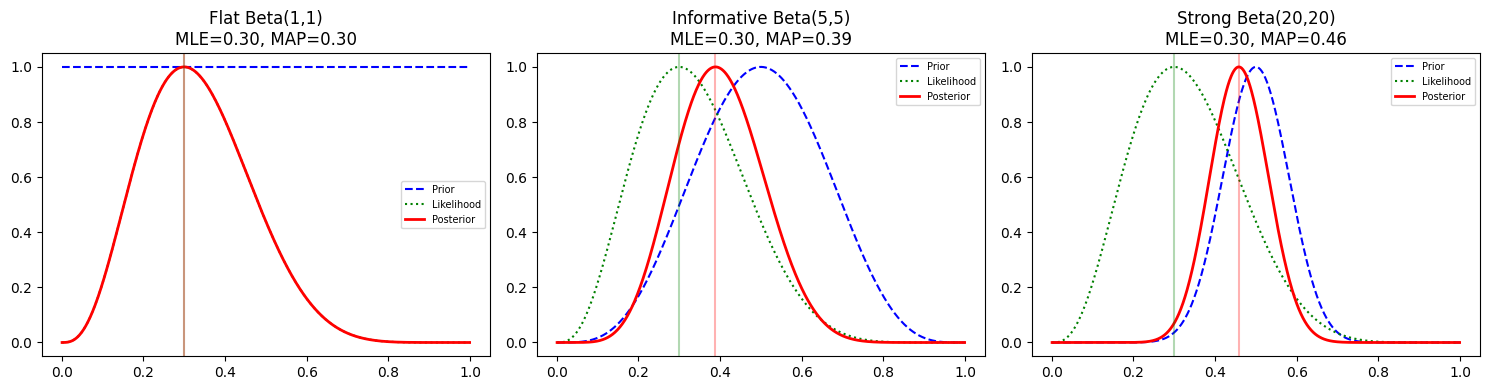

Key insight: stronger prior pulls MAP further from MLE


In [5]:
# Compare MAP vs MLE with different priors
n_heads, n_flips = 3, 10
x = np.linspace(0.001, 0.999, 1000)

priors = {'Flat Beta(1,1)': (1,1), 'Informative Beta(5,5)': (5,5), 'Strong Beta(20,20)': (20,20)}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (a, b)) in zip(axes, priors.items()):
    prior = stats.beta.pdf(x, a, b)
    lik = stats.binom.pmf(n_heads, n_flips, x)
    post = prior * lik; post /= post.max()
    lik_norm = lik / lik.max()
    prior_norm = prior / prior.max()
    ax.plot(x, prior_norm, 'b--', label='Prior')
    ax.plot(x, lik_norm, 'g:', label='Likelihood')
    ax.plot(x, post, 'r-', linewidth=2, label='Posterior')
    mle = n_heads / n_flips
    map_est = x[np.argmax(post)]
    ax.axvline(x=mle, color='green', alpha=0.3)
    ax.axvline(x=map_est, color='red', alpha=0.3)
    ax.set_title(f'{name}\nMLE={mle:.2f}, MAP={map_est:.2f}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
print('Key insight: stronger prior pulls MAP further from MLE')

---
## 4. Metropolis-Hastings MCMC (from scratch)

MCMC samples from distributions we can't compute analytically.  
The algorithm proposes moves and accepts/rejects based on the target density ratio.

Acceptance rate: 66.7%


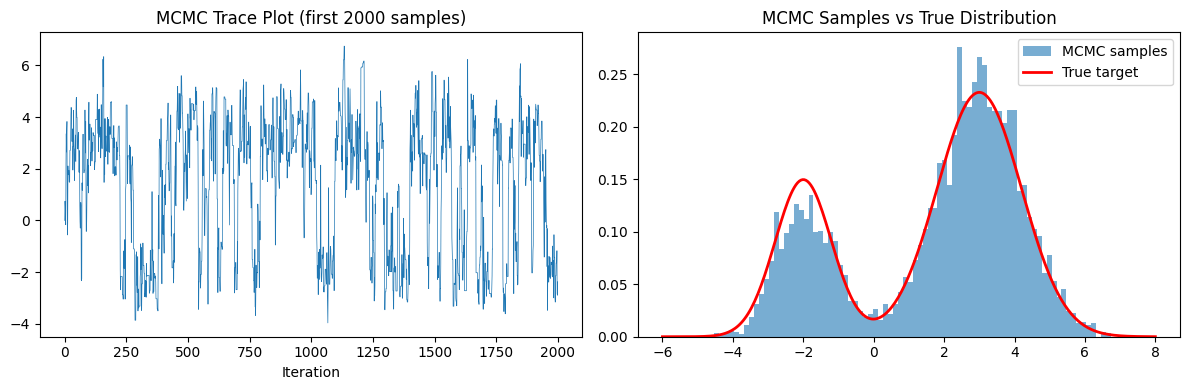

In [6]:
# Metropolis-Hastings to sample from a mixture of two Gaussians
def target_pdf(x):
    return 0.3 * stats.norm.pdf(x, -2, 0.8) + 0.7 * stats.norm.pdf(x, 3, 1.2)

n_samples = 10000
samples = np.zeros(n_samples)
samples[0] = 0  # starting point
accepted = 0

for i in range(1, n_samples):
    proposal = samples[i-1] + np.random.normal(0, 1.5)  # random walk proposal
    ratio = target_pdf(proposal) / target_pdf(samples[i-1])
    if np.random.rand() < min(1, ratio):
        samples[i] = proposal
        accepted += 1
    else:
        samples[i] = samples[i-1]

print(f'Acceptance rate: {accepted/n_samples:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Trace plot
axes[0].plot(samples[:2000], linewidth=0.5)
axes[0].set_title('MCMC Trace Plot (first 2000 samples)')
axes[0].set_xlabel('Iteration')
# Histogram vs true
x = np.linspace(-6, 8, 300)
axes[1].hist(samples[1000:], bins=80, density=True, alpha=0.6, label='MCMC samples')
axes[1].plot(x, target_pdf(x), 'r-', linewidth=2, label='True target')
axes[1].set_title('MCMC Samples vs True Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 5. Credible Interval vs Confidence Interval

In [7]:
# Bayesian credible interval from posterior
a_post, b_post = 2 + 14, 2 + 6  # Beta posterior after 14 heads, 6 tails
cred_lo, cred_hi = stats.beta.ppf([0.025, 0.975], a_post, b_post)
print(f'95% Credible Interval: ({cred_lo:.3f}, {cred_hi:.3f})')
print(f'  Interpretation: 95% probability θ is in this interval (given data + prior)')

# Frequentist confidence interval
from statsmodels.stats.proportion import proportion_confint
ci_lo, ci_hi = proportion_confint(14, 20, alpha=0.05, method='wilson')
print(f'\n95% Confidence Interval: ({ci_lo:.3f}, {ci_hi:.3f})')
print(f'  Interpretation: 95% of such intervals contain the true θ')

95% Credible Interval: (0.471, 0.836)
  Interpretation: 95% probability θ is in this interval (given data + prior)



95% Confidence Interval: (0.481, 0.855)
  Interpretation: 95% of such intervals contain the true θ


---
## Key Interview Takeaways

1. **Posterior ∝ Likelihood × Prior** — Bayes' rule is the foundation
2. **Conjugate priors** — Beta-Binomial is the classic example; posterior stays in same family
3. **MAP = MLE when prior is flat** — prior matters with small data
4. **MCMC** — sample from distributions we can't compute analytically
5. **Credible vs Confidence intervals** — Bayesian gives direct probability statements about parameters

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>